In [233]:
from typing import Optional, Tuple

import numpy as np
import matplotlib.pyplot as plt

def plot_3d_surface(
    x: np.ndarray,
    t: np.ndarray,
    U: np.ndarray,
    title: str,
    filename: Optional[str] = None,
    cmap: str = 'viridis',
    azim: int = -60
) -> Tuple[plt.Figure, plt.Axes]:
    fig = plt.figure(figsize=(12, 8))
    ax = fig.add_subplot(111, projection='3d')
    X, T_grid = np.meshgrid(x, t)
    surf = ax.plot_surface(X, T_grid, U, cmap=cmap, edgecolor='none', alpha=0.9)
    ax.set_xlabel('x', fontsize=12)
    ax.set_ylabel('t', fontsize=12)
    ax.set_zlabel('U(x,t)', fontsize=12)
    ax.set_title(title, fontsize=14)
    ax.view_init(elev=25, azim=azim)
    cbar = fig.colorbar(surf, ax=ax, shrink=0.6)
    cbar.set_label('U(x,t)', rotation=270, labelpad=15)
    plt.tight_layout()
    if filename:
        plt.savefig(filename, dpi=150, bbox_inches='tight')
    plt.show()
    return fig, ax


In [234]:
def f(x, t):
    return x

def u_start(x):
    return 7 * x

def u_left(t: float) -> float:
    return 7 * t

def u_right(t: float) -> float:
    return 2 * t + 7

In [235]:
a_pos = 2
a_neg = -2

x_start = 0
x_end = 1

t_start = 0
t_end = 10

h = 0.1
tau = h / a_pos

In [236]:
nx = int((x_end - x_start) / h + 1)
nt = int((t_end - t_start) / tau + 1)

x = [x_start + i * h for i in range(nx)]
t = [t_start + i * tau for i in range(nt)]

In [237]:
lam = a_pos * tau / h

u = [([0] * nx) for _ in range(nt)]

for i in range(nx):
    xi = x[i]
    u[0][i] = u_start(xi)

In [238]:
for j in range(nt - 1):
    tj = t[j]
    for i in range(1, nx):
        xi = x[i]
        u[j + 1][i] = u[j][i] - lam * (u[j][i] - u[j][i - 1]) + tau * f(xi, tj)

    u[j + 1][0] = u_left(t[j + 1])

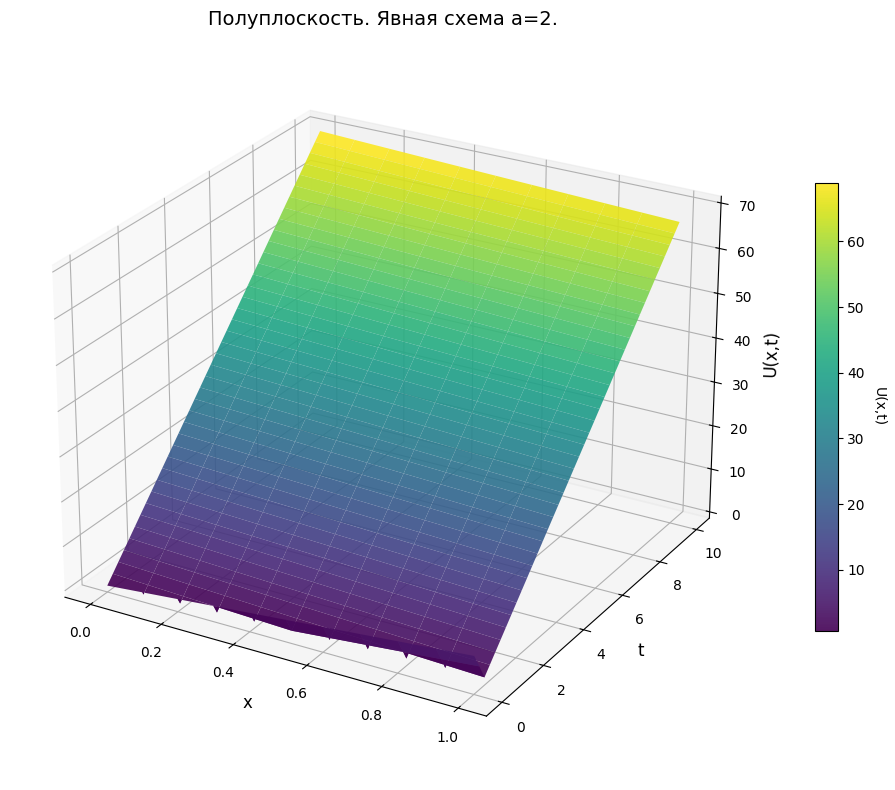

(<Figure size 1200x800 with 2 Axes>,
 <Axes3D: title={'center': 'Полуплоскость. Явная схема a=2.'}, xlabel='x', ylabel='t', zlabel='U(x,t)'>)

In [239]:
plot_3d_surface(
    np.array(x),
    np.array(t),
    np.array(u),
    "Полуплоскость. Явная схема a=2.",
    filename="Полуплоскость. Явная схема a=2.",
    cmap='viridis'
)

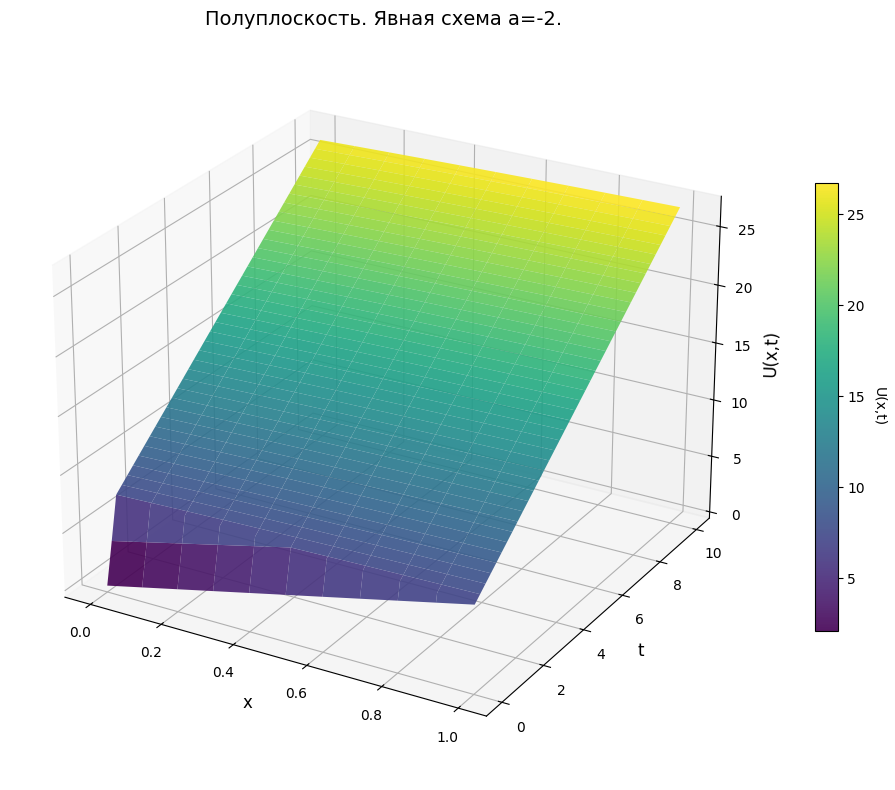

(<Figure size 1200x800 with 2 Axes>,
 <Axes3D: title={'center': 'Полуплоскость. Явная схема a=-2.'}, xlabel='x', ylabel='t', zlabel='U(x,t)'>)

In [240]:
lam = a_neg * tau / h
u = [([0] * nx) for _ in range(nt)]

for i in range(nx):
    xi = x[i]
    u[0][i] = u_start(xi)

for j in range(nt - 1):
    tj = t[j]
    for i in range(nx - 2, -1, -1):
        xi = x[i]
        u[j + 1][i] = u[j][i] - lam * (u[j][i + 1] - u[j][i]) + tau * f(xi, tj)

    u[j + 1][nx - 1] = u_right(t[j + 1])

plot_3d_surface(
    np.array(x),
    np.array(t),
    np.array(u),
    "Полуплоскость. Явная схема a=-2.",
    filename="Полуплоскость. Явная схема a=-2.",
    cmap='viridis'
)

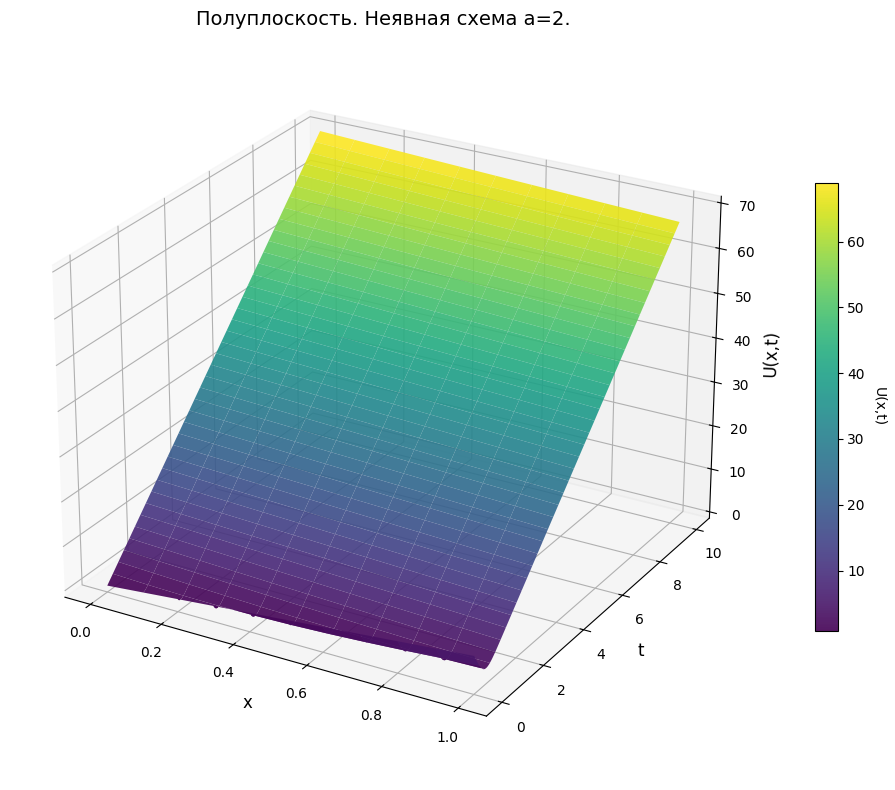

(<Figure size 1200x800 with 2 Axes>,
 <Axes3D: title={'center': 'Полуплоскость. Неявная схема a=2.'}, xlabel='x', ylabel='t', zlabel='U(x,t)'>)

In [241]:
lam = a_pos * tau / h

u = [([0] * nx) for _ in range(nt)]

for i in range(nx):
    xi = x[i]
    u[0][i] = u_start(xi)

for j in range(nt - 1):
    tj = t[j]
    u[j + 1][0] = u_left(t[j + 1])
    for i in range(1, nx):
        xi = x[i]
        u[j + 1][i] = (u[j][i] + lam * u[j + 1][i - 1] + tau * f(xi, tj)) / (1 + lam)

plot_3d_surface(
    np.array(x),
    np.array(t),
    np.array(u),
    "Полуплоскость. Неявная схема a=2.",
    filename="Полуплоскость. Неявная схема a=2.",
    cmap='viridis'
)

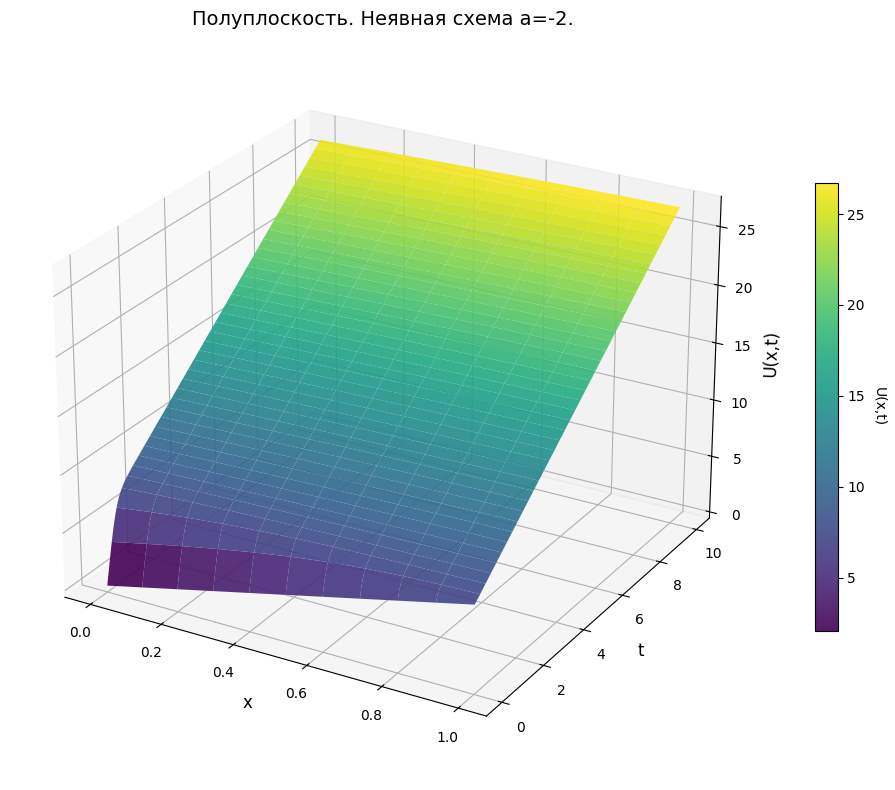

(<Figure size 1200x800 with 2 Axes>,
 <Axes3D: title={'center': 'Полуплоскость. Неявная схема a=-2.'}, xlabel='x', ylabel='t', zlabel='U(x,t)'>)

In [242]:
lam = a_neg * tau / h
u = [([0] * nx) for _ in range(nt)]

for i in range(nx):
    xi = x[i]
    u[0][i] = u_start(xi)

for j in range(nt - 1):
    tj = t[j]
    u[j + 1][nx - 1] = u_right(t[j + 1])

    for i in range(nx - 2, -1, -1):
        xi = x[i]
        u[j + 1][i] = (u[j][i] - lam * u[j + 1][i + 1] + tau * f(xi, tj)) / (1 - lam)

plot_3d_surface(
    np.array(x),
    np.array(t),
    np.array(u),
    "Полуплоскость. Неявная схема a=-2.",
    filename="Полуплоскость. Неявная схема a=-2.",
    cmap='viridis'
)

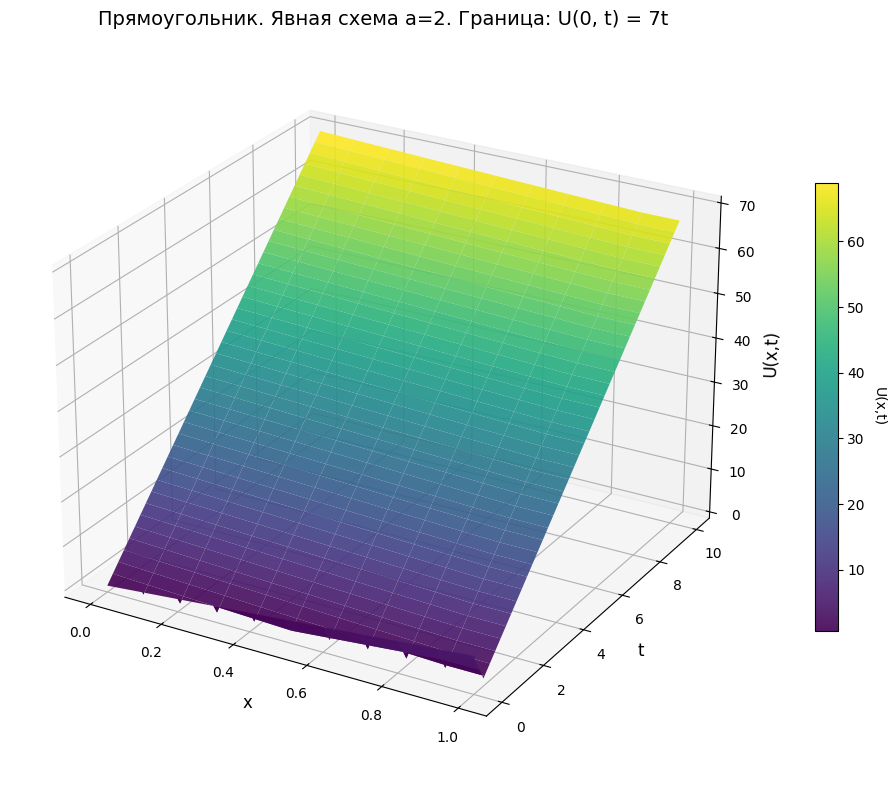

(<Figure size 1200x800 with 2 Axes>,
 <Axes3D: title={'center': 'Прямоугольник. Явная схема a=2. Граница: U(0, t) = 7t'}, xlabel='x', ylabel='t', zlabel='U(x,t)'>)

In [243]:
lam = a_pos * tau / h

u = [([0] * nx) for _ in range(nt)]

for i in range(nx):
    xi = x[i]
    u[0][i] = u_start(xi)
for j in range(nt - 1):
    tj = t[j]
    u[j + 1][0] = u_left(t[j + 1])

    for i in range(1, nx - 1):
        xi = x[i]
        u[j + 1][i] = u[j][i] - lam * (u[j][i] - u[j][i - 1]) + tau * f(xi, tj)

    u[j + 1][nx - 1] = u[j + 1][nx - 2]

plot_3d_surface(
    np.array(x),
    np.array(t),
    np.array(u),
    "Прямоугольник. Явная схема a=2. Граница: U(0, t) = 7t",
    filename="Прямоугольник. Явная схема a=2. Граница - U(0, t) 7t.png",
    cmap='viridis'
)

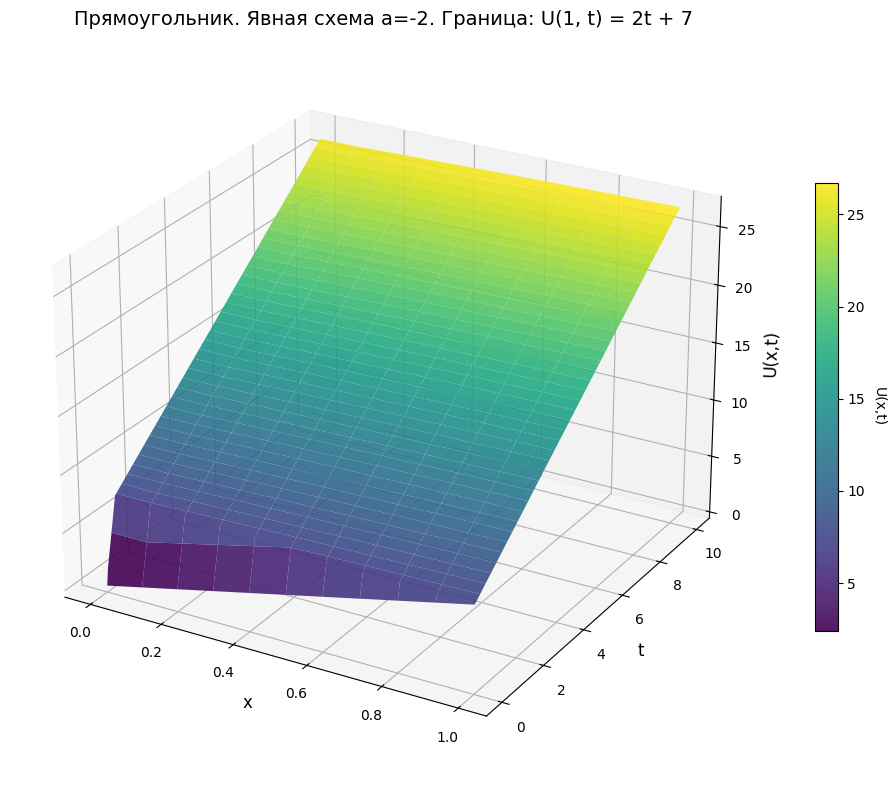

(<Figure size 1200x800 with 2 Axes>,
 <Axes3D: title={'center': 'Прямоугольник. Явная схема a=-2. Граница: U(1, t) = 2t + 7'}, xlabel='x', ylabel='t', zlabel='U(x,t)'>)

In [244]:
lam = a_neg * tau / h
u = [([0] * nx) for _ in range(nt)]

for i in range(nx):
    xi = x[i]
    u[0][i] = u_start(xi)

for j in range(nt - 1):
    tj = t[j]

    u[j + 1][nx - 1] = u_right(t[j + 1])

    for i in range(nx - 2, 0, -1):
        xi = x[i]
        u[j + 1][i] = u[j][i] - lam * (u[j][i + 1] - u[j][i]) + tau * f(xi, tj)

    u[j + 1][0] = u[j + 1][1]

plot_3d_surface(
    np.array(x),
    np.array(t),
    np.array(u),
    "Прямоугольник. Явная схема a=-2. Граница: U(1, t) = 2t + 7",
    filename="Прямоугольник. Явная схема a=-2. Граница - U(1, t) 2t + 7.png",
    cmap='viridis'
)

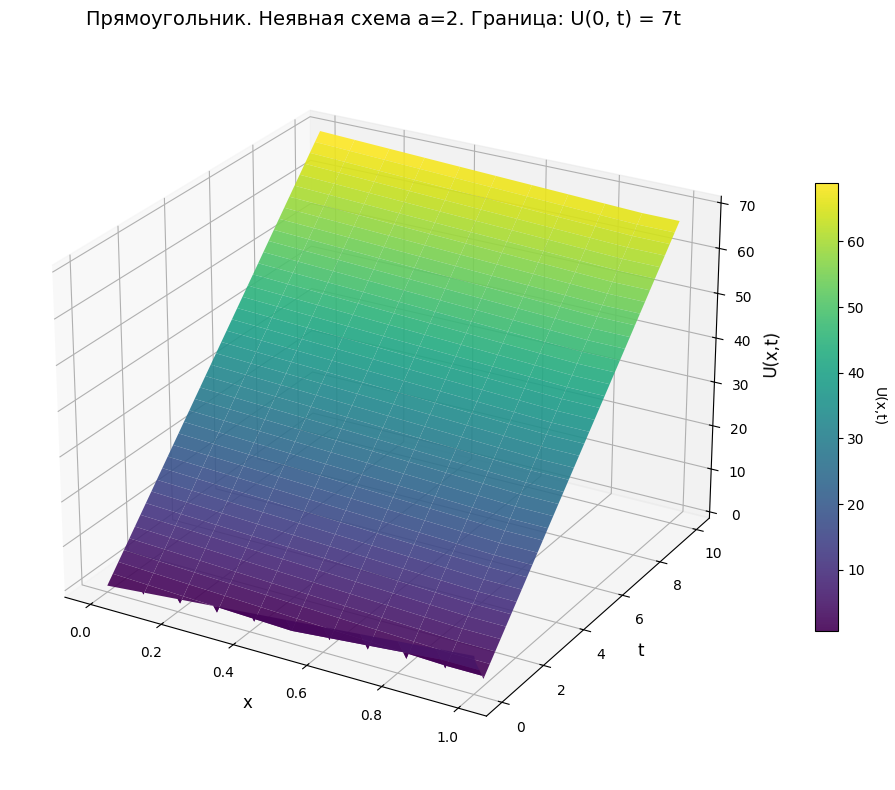

(<Figure size 1200x800 with 2 Axes>,
 <Axes3D: title={'center': 'Прямоугольник. Неявная схема a=2. Граница: U(0, t) = 7t'}, xlabel='x', ylabel='t', zlabel='U(x,t)'>)

In [245]:
lam = a_pos * tau / h

u = [([0] * nx) for _ in range(nt)]

for i in range(nx):
    xi = x[i]
    u[0][i] = u_start(xi)
for j in range(nt - 1):
    tj = t[j]
    u[j + 1][0] = u_left(t[j + 1])

    for i in range(1, nx - 1):
        xi = x[i]
        u[j + 1][i] = (u[j][i - 1] * (1 + lam) + (u[j][i] - u[j + 1][i - 1]) * (1 - lam) + tau * f(xi + h/2, tj + 2 * tau/2)) / (1 + lam)

    u[j + 1][nx - 1] = u[j + 1][nx - 2]

plot_3d_surface(
    np.array(x),
    np.array(t),
    np.array(u),
    "Прямоугольник. Неявная схема a=2. Граница: U(0, t) = 7t",
    filename="Прямоугольник. Неявная схема a=2. Граница - U(0, t) 7t.png",
    cmap='viridis'
)

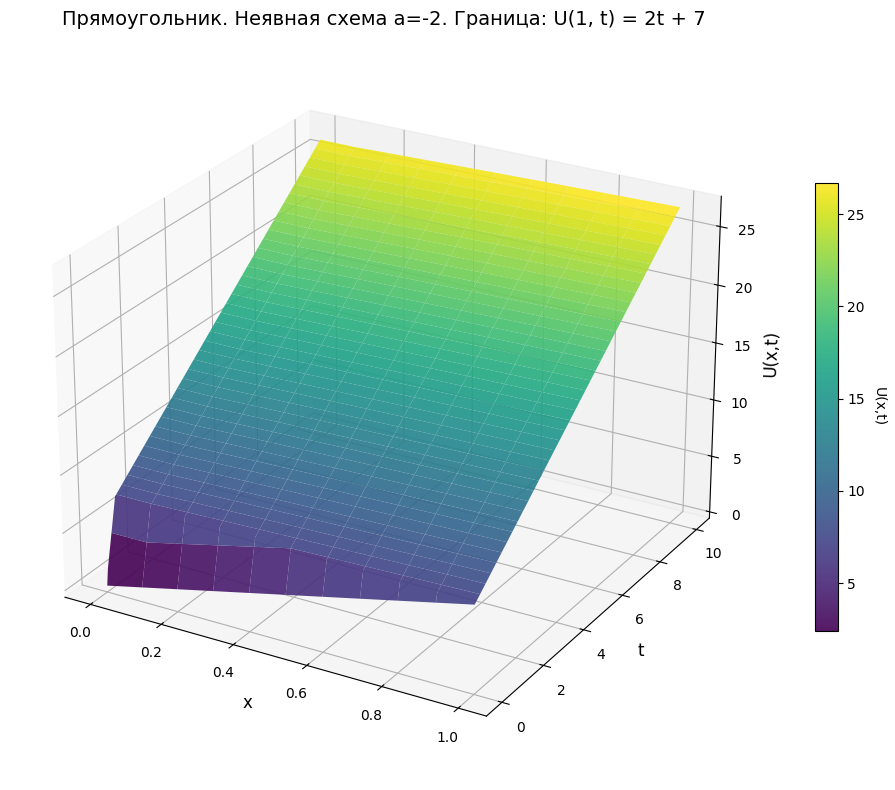

(<Figure size 1200x800 with 2 Axes>,
 <Axes3D: title={'center': 'Прямоугольник. Неявная схема a=-2. Граница: U(1, t) = 2t + 7'}, xlabel='x', ylabel='t', zlabel='U(x,t)'>)

In [249]:
lam = a_neg * tau / h
u = [([0] * nx) for _ in range(nt)]

for i in range(nx):
    xi = x[i]
    u[0][i] = u_start(xi)

for j in range(nt - 1):
    tj = t[j]

    u[j + 1][nx - 1] = u_right(t[j + 1])

    for i in range(nx - 1, 0, -1):
        xi = x[i]
        u[j + 1][i - 1] = ((1 - lam) * u[j][i] + (lam + 1) * (u[j][i-1] - u[j+1][i]) + tau * f(xi + h/2, tj + tau/2)) / (1 - lam)

    u[j + 1][0] = u[j + 1][1]

plot_3d_surface(
    np.array(x),
    np.array(t),
    np.array(u),
    "Прямоугольник. Неявная схема a=-2. Граница: U(1, t) = 2t + 7",
    filename="Прямоугольник. Неявная схема a=-2. Граница - U(1, t) 2t + 7.png",
    cmap='viridis'
)